# EC-Earth Station Susceptibility — Aitken vs Accumulation Mode

**Question:** Does the CCN→CDNC susceptibility (d ln CDNC / d ln CCN) differ between
columns dominated by *Aitken-mode* aerosol versus *accumulation-mode* aerosol, in EC-Earth?

Mirrors the NorESM aitacc analysis: (1) compute an Aitken-to-accumulation number ratio
from the EC-Earth size distribution, (2) split into high-Aitken (top quartile) and
high-accumulation (bottom quartile) populations per station, then (3) regress log CDNC
on log CCN within each population.

*No updraft stratification in EC-Earth (WSUB is not available).*

## 1. Setup and data load

In [1]:
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


In [2]:
# --- Paths, time window, and analysis grid ---
ECPath = "/share/sabl0586/all_stations_EC-Earth_PRCP2SZDST_ilevall_levs_4Peter.nc"

# Pre-extracted EC-Earth aerosol fields and the IFS variables already regridded
# onto EC-Earth's 34 model levels (see Function.ECearthExtract_Dask).
ds    = xr.open_dataset('/share/pech2273/EC_Earth_Data.nc').chunk(time=1000)
dsIFS = xr.open_dataset('/share/pech2273/EC_Earth_Data_IFS_34_levels.nc').chunk(time=1000)

stations = ds["station"].values
radii = np.logspace(0, 2.7, 61)   # 1 -> ~500 nm RADIUS, log-spaced (diameter = 2*radius)
x = xr.DataArray(np.logspace(-0.5, 3, num=200), dims=['D'],
                 coords={'D': np.logspace(-0.5, 3, num=200)})  # diameter grid for PNSD integration

# Common 3-year window
tslice = slice('2012-01-01T03:00:00', '2015-01-01T03:00:00')
ds    = ds.sel(time=tslice)
dsIFS = dsIFS.sel(time=tslice)


## 2. Build the per-station CCN / CDNC dataset

In [3]:
# --- Normalise modal radius/number units for the ERF integration ---
# EC-Earth stores 7 lognormal modes; radii must be nm and numbers #/cm3 before ECEarthERF.
radius_variables = ['RDRY_NUS', 'RDRY_AIS', 'RDRY_ACS', 'RWET_AII', 'RDRY_COS', 'RWET_ACI', 'RWET_COI']
Numb_variables   = ['N_NUS', 'N_AIS', 'N_ACS', 'N_AII', 'N_COS', 'N_ACI', 'N_COI']
ModesSigma       = [1.59, 1.59, 1.59, 2.0, 1.59, 1.59, 2.0]

for radius, number in zip(radius_variables, Numb_variables):
    if radius in ds and number in ds:
        if ds[radius].attrs.get('units') == 'm':
            ds[radius] = ds[radius] * 1e9
            ds[radius].attrs['units'] = 'nm'
            print(f'{radius} changed to nm')
        if ds[number].attrs.get('units') == '1 m-3':
            ds[number] = ds[number] / 1e6
            ds[number].attrs['units'] = '#cm-3'
            print(f'{number} converted to #cm-3')
    else:
        print(f'{(radius, number)} not found in EC data')


RDRY_NUS changed to nm
N_NUS converted to #cm-3
RDRY_AIS changed to nm
N_AIS converted to #cm-3
RDRY_ACS changed to nm
N_ACS converted to #cm-3
RWET_AII changed to nm
N_AII converted to #cm-3
RDRY_COS changed to nm
N_COS converted to #cm-3
RWET_ACI changed to nm
N_ACI converted to #cm-3
RWET_COI changed to nm
N_COI converted to #cm-3


In [4]:
def CCN_CDNC_Dataset(CCN_ds, CDNC_da):
    """Pair CCN(radius, lev, time) with CDNC(lev, time), aligned on shared coords."""
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)
    return xr.Dataset(
        data_vars={'CCN': CCN_aligned, 'CDNC': CDNC_aligned},
        coords={'radius': CCN_aligned.radius,
                'lev': CCN_aligned.lev,
                'time': CCN_aligned.time},
    )


In [5]:
# --- CDNC from the IFS variables, masked to cloudy points ---
# CDNC = var20 / var22; var22 >= 8640 is the EC-Earth equivalent of FREQL > 0.8
# (>80% cloud cover), keeping the same cloud mask as the NorESM analysis.
cdnc = (dsIFS['var20'] / dsIFS['var22']).where(dsIFS['var22'] >= 8640.0)
cdnc = cdnc.rename({'level_tgt': 'lev'})

# Integrate the modal PNSD into cumulative CCN(>r), then pair with CDNC.
CCN_ds = Function.ECEarthERF(ds, radii)
CCN_all = CCN_CDNC_Dataset(CCN_ds, cdnc).compute()   # force eval once; masking is heavy


/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesi

/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


## 3. Aitken / accumulation ratio and its distribution

In [6]:
# === Aitken-to-accumulation ratio (the size-distribution shape metric) ===
# ECEarthERF integrates the modal PNSD above a radius cutoff, giving cumulative
# number concentration N(>r). Cutoffs are 10 nm and 50 nm RADIUS (= 20 / 100 nm DIAMETER).
AitAcc_ds = Function.ECEarthERF(ds, [10, 50]).sel(time=tslice)

N20  = AitAcc_ds.sel(radius=10)   # N(>20 nm diameter): Aitken + accumulation + coarse
N100 = AitAcc_ds.sel(radius=50)   # N(>100 nm diameter): accumulation + coarse only

# (N20 - N100) / N100 :  20-100 nm band (~Aitken) over accumulation population.
# High ratio -> Aitken-dominated (clean/fresh); low ratio -> accumulation-dominated (aged).

TotalAitAccRatio = ((N20 - N100) / N100).compute()

# Split by whether a cloud-base CDNC sample exists at that point.
AitAccRatio2 = TotalAitAccRatio.compute().where(CCN_all.CDNC.isnull(),  drop=True)  # no CDNC
AitAccRatio  = TotalAitAccRatio.compute().where(CCN_all.CDNC.notnull(), drop=True)  # with CDNC


Quartiles of the ratio — the Q25 / Q75 cuts used below to define the two populations.

In [7]:
print(f'Ait/Acc ratio 25th pct (all):       {TotalAitAccRatio.quantile(0.25).values:.3f}')
print(f'Ait/Acc ratio 25th pct (with CDNC): {AitAccRatio.quantile(0.25).values:.3f}')
print(f'Ait/Acc ratio 75th pct (with CDNC): {AitAccRatio.quantile(0.75).values:.3f}')


Ait/Acc ratio 25th pct (all):       1.865
Ait/Acc ratio 25th pct (with CDNC): 1.349
Ait/Acc ratio 75th pct (with CDNC): 3.004


Distribution of the ratio (per station, and pooled with/without CDNC).

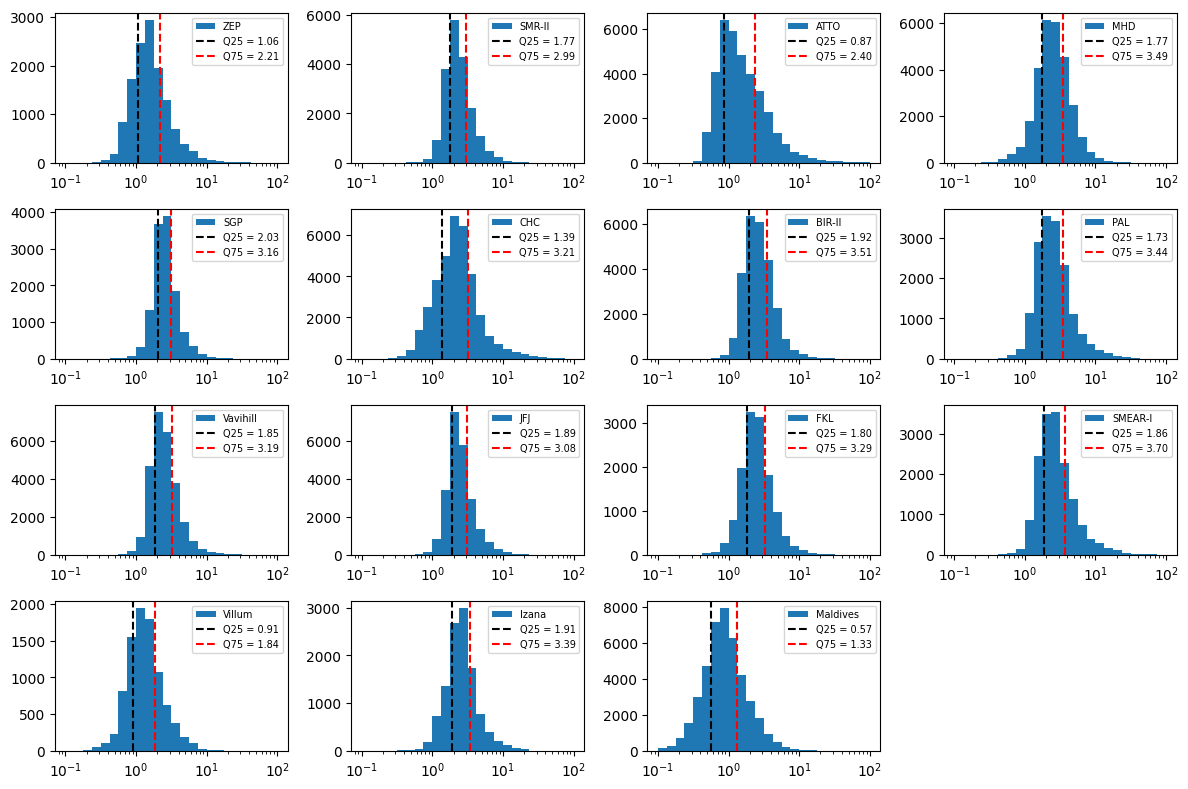

In [24]:
bins = np.logspace(-1, 2, 25)
plt.figure(figsize=[12, 8])
for x, station in enumerate(AitAccRatio.station.values):
    plt.subplot(4, 4, x + 1)
    data = AitAccRatio.sel(station=station).values.ravel()
    plt.hist(data, bins=bins, label=station)

    q25, q75 = np.nanquantile(data, [0.25, 0.75])
    plt.axvline(q25, color='k', linestyle='--', linewidth=1.5,
                label=f'Q25 = {q25:.2f}')
    plt.axvline(q75, color='r', linestyle='--', linewidth=1.5,
                label=f'Q75 = {q75:.2f}')

    plt.xscale('log')
    plt.legend(fontsize=7)
plt.tight_layout()


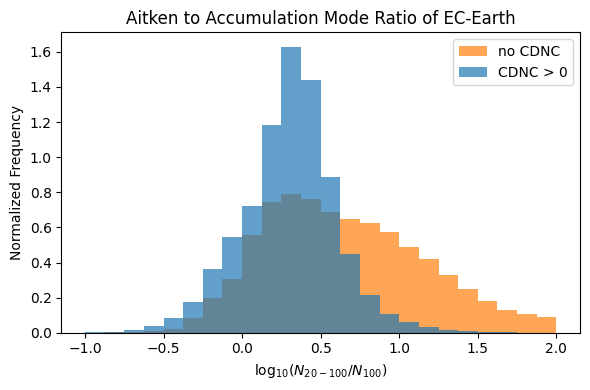

In [9]:
bins = np.linspace(-1, 2, 25)
plt.figure(figsize=[6, 4])
plt.hist(
    [np.log10(AitAccRatio.values.flatten()), np.log10(AitAccRatio2.values.flatten())],
    density=True, bins=bins, stacked=False, histtype='stepfilled', alpha=0.7,
    label=['CDNC > 0', 'no CDNC'],
)
plt.ylabel('Normalized Frequency')
plt.xlabel('log$_{10}$($N_{20-100}/N_{100}$)')
plt.title('Aitken to Accumulation Mode Ratio of EC-Earth')
plt.legend()
plt.tight_layout()


## 4. Define the high-Aitken and high-accumulation populations

Lower quartile of the ratio = accumulation-dominated (`BigAcc`); upper quartile =
Aitken-dominated (`BigAit`). Quartiles are computed per station so a few
stations don't dominate the global cut.

In [10]:
# --- Per-station quartile split ---
# AitAccRatio already restricted to CDNC-present points; collapse stray coords.
ratio = AitAccRatio.reset_coords(drop=True)   # drop time_orig/lev_ifs/radius hangers-on

dims = [d for d in ratio.dims if d != "station"]

q25 = ratio.quantile(0.25, dim=dims, skipna=True)
q75 = ratio.quantile(0.75, dim=dims, skipna=True)

# Masks are NaN-safe: a NaN ratio yields False, so it's excluded from both.
mask_acc = ratio <= q25
mask_ait = ratio >= q75

BigAcc = CCN_all.where(mask_acc)
BigAit = CCN_all.where(mask_ait)

BigAcc = BigAcc.where(BigAcc.CDNC.notnull(), drop=True)
BigAit = BigAit.where(BigAit.CDNC.notnull(), drop=True)



## 5. Stack into (CCN, CDNC) sample pairs

Broadcast CCN against CDNC and flatten station/time/lev into a single `sample`
dimension. No updraft term in EC-Earth, so the pairs carry only CCN and CDNC.

In [11]:
def stack_pairs(big_ds):
    """Flatten (station, time, lev) into one 'sample' dim; keep CCN(radius, sample), CDNC(sample)."""
    stack_dims = ['station', 'time', 'lev']
    return xr.Dataset({
        'CCN':  big_ds.CCN.stack(sample=stack_dims),    # (radius, sample)
        'CDNC': big_ds.CDNC.stack(sample=stack_dims),   # (sample,) -- no radius axis
    })

Pairs_acc = stack_pairs(BigAcc)
Pairs_ait = stack_pairs(BigAit)


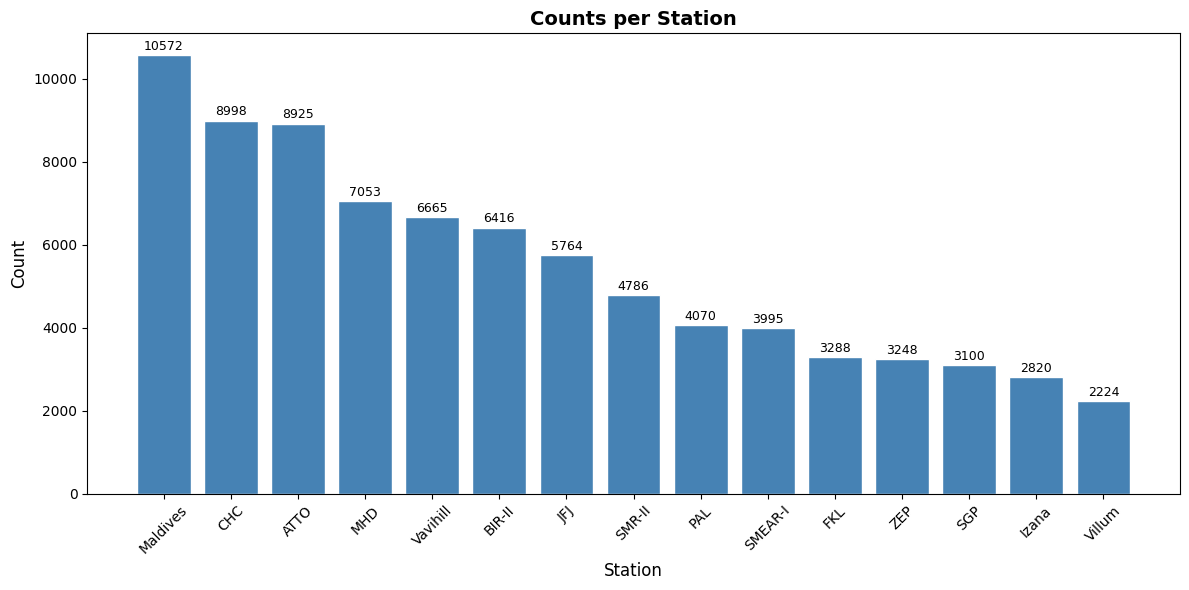

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Count only valid samples (drop NaN-CDNC points that survive in the stacked array)
valid = np.isfinite(Pairs_ait.CDNC.values)
stations = Pairs_ait.station.values[valid]
station_counts = pd.Series(stations).value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(station_counts.index, station_counts.values, color='steelblue', edgecolor='white')

for bar, count in zip(bars, station_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            str(count), ha='center', va='bottom', fontsize=9)

ax.set_title('Counts per Station', fontsize=14, fontweight='bold')
ax.set_xlabel('Station', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 6. Pooled susceptibility regression

Regress log CDNC on log CCN at each cutoff radius, pooled over all samples (no updraft
bands). Same equal-count log-CCN binning + per-bin median convention as the NorESM
notebook; the slope is the susceptibility S = d ln CDNC / d ln CCN.

In [13]:
def pooled_susceptibility(pairs_ds, radii, n_bins=100, bin_dim='radius'):
    """Pooled log CDNC vs log CCN per cutoff radius, equal-count bins through bin medians."""
    out = xr.Dataset(
        data_vars={
            'slope':     ([bin_dim], np.full(len(radii), np.nan)),
            'r_value':   ([bin_dim], np.full(len(radii), np.nan)),
            'std_err':   ([bin_dim], np.full(len(radii), np.nan)),
            'intercept': ([bin_dim], np.full(len(radii), np.nan)),
        },
        coords={bin_dim: radii},
    )
    for r_idx, r_val in enumerate(radii):
        CCN  = pairs_ds['CCN'].isel({bin_dim: r_idx}).values
        CDNC = pairs_ds['CDNC'].values
        valid = (CCN > 0) & (CDNC > 0) & np.isfinite(CCN) & np.isfinite(CDNC)
        lx = np.log10(CCN[valid]); ly = np.log10(CDNC[valid])
        if lx.size < 10:
            continue
        order = np.argsort(lx)
        lx_g = np.array_split(lx[order], n_bins)
        ly_g = np.array_split(ly[order], n_bins)
        lx_med = np.array([np.median(g) for g in lx_g if g.size > 0])
        ly_med = np.array([np.median(g) for g in ly_g if g.size > 0])
        finite = np.isfinite(lx_med) & np.isfinite(ly_med)
        if finite.sum() < 4:
            continue
        slope, intercept, r_value, p_value, std_err = stats.linregress(lx_med[finite], ly_med[finite])
        out['slope'].loc[{bin_dim: r_val}]     = slope
        out['r_value'].loc[{bin_dim: r_val}]   = r_value
        out['std_err'].loc[{bin_dim: r_val}]   = std_err
        out['intercept'].loc[{bin_dim: r_val}] = intercept
    return out


In [14]:
BigAitReg_ds = pooled_susceptibility(Pairs_ait, radii)   # high-Aitken population
BigAccReg_ds = pooled_susceptibility(Pairs_acc, radii)   # high-accumulation population


## 7. Susceptibility resolved by vertical level

Same regression looped per model level instead of pooled, to see how susceptibility
varies with height.

In [15]:
import warnings
acc_count = pd.Series(Pairs_acc.lev.values).value_counts().sort_index()
all_levels = acc_count.index

N_BINS = 100

BigAccReg_lev_ds = xr.Dataset(
    data_vars={
        "slope":     (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "r_value":   (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "std_err":   (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "intercept": (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
    },
    coords={"radius": radii, "lev": all_levels},
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    for level in all_levels:
        for r in range(len(radii)):
            CCN  = Pairs_acc.CCN.sel(lev=level).isel(radius=r).values
            CDNC = Pairs_acc.CDNC.sel(lev=level).values
            valid = (CCN > 0) & (CDNC > 0) & np.isfinite(CCN) & np.isfinite(CDNC)
            lx = np.log10(CCN[valid]); ly = np.log10(CDNC[valid])
            if lx.size < 10:
                continue
            # equal-count bins -> per-bin medians
            order = np.argsort(lx)
            lx_g = np.array_split(lx[order], N_BINS)
            ly_g = np.array_split(ly[order], N_BINS)
            lx_med = np.array([np.median(g) for g in lx_g if g.size > 0])
            ly_med = np.array([np.median(g) for g in ly_g if g.size > 0])
            finite = np.isfinite(lx_med) & np.isfinite(ly_med)
            if finite.sum() < 4:
                continue
            slope, intercept, r_value, p_value, std_err = stats.linregress(lx_med[finite], ly_med[finite])
            loc = {"radius": radii[r], "lev": level}
            BigAccReg_lev_ds["slope"].loc[loc]     = slope
            BigAccReg_lev_ds["r_value"].loc[loc]   = r_value
            BigAccReg_lev_ds["std_err"].loc[loc]   = std_err
            BigAccReg_lev_ds["intercept"].loc[loc] = intercept


In [16]:
import warnings
ait_count = pd.Series(Pairs_ait.lev.values).value_counts().sort_index()
all_levels = ait_count.index

N_BINS = 100

BigAitReg_lev_ds = xr.Dataset(
    data_vars={
        "slope":     (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "r_value":   (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "std_err":   (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "intercept": (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
    },
    coords={"radius": radii, "lev": all_levels},
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    for level in all_levels:
        for r in range(len(radii)):
            CCN  = Pairs_ait.CCN.sel(lev=level).isel(radius=r).values
            CDNC = Pairs_ait.CDNC.sel(lev=level).values
            valid = (CCN > 0) & (CDNC > 0) & np.isfinite(CCN) & np.isfinite(CDNC)
            lx = np.log10(CCN[valid]); ly = np.log10(CDNC[valid])
            if lx.size < 10:
                continue
            # equal-count bins -> per-bin medians
            order = np.argsort(lx)
            lx_g = np.array_split(lx[order], N_BINS)
            ly_g = np.array_split(ly[order], N_BINS)
            lx_med = np.array([np.median(g) for g in lx_g if g.size > 0])
            ly_med = np.array([np.median(g) for g in ly_g if g.size > 0])
            finite = np.isfinite(lx_med) & np.isfinite(ly_med)
            if finite.sum() < 4:
                continue
            slope, intercept, r_value, p_value, std_err = stats.linregress(lx_med[finite], ly_med[finite])
            loc = {"radius": radii[r], "lev": level}
            BigAitReg_lev_ds["slope"].loc[loc]     = slope
            BigAitReg_lev_ds["r_value"].loc[loc]   = r_value
            BigAitReg_lev_ds["std_err"].loc[loc]   = std_err
            BigAitReg_lev_ds["intercept"].loc[loc] = intercept


## 8. Susceptibility maps: diameter × model level

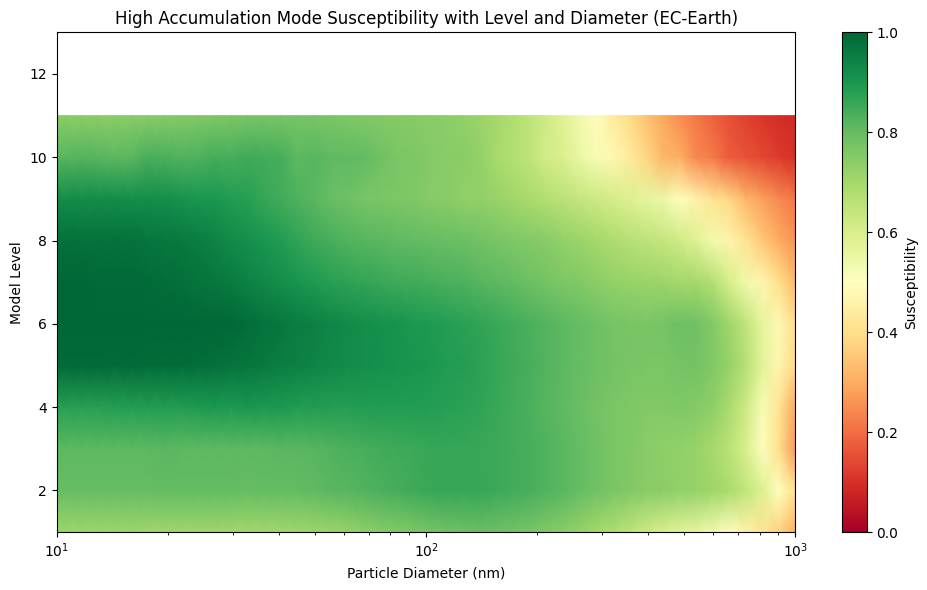

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
mesh = ax.pcolormesh(
    BigAccReg_lev_ds['radius'] * 2,
    BigAccReg_lev_ds['lev'],
    BigAccReg_lev_ds['slope'].T,
    shading='gouraud', vmin=0, vmax=1, cmap='RdYlGn',
)
ax.set_xscale('log')
ax.set_xlim(10, 1000)
ax.set_xlabel('Particle Diameter (nm)')
ax.set_ylabel('Model Level')
ax.set_title('High Accumulation Mode Susceptibility with Level and Diameter (EC-Earth)')
plt.colorbar(mesh, ax=ax, label='Susceptibility')
plt.tight_layout()
plt.show()


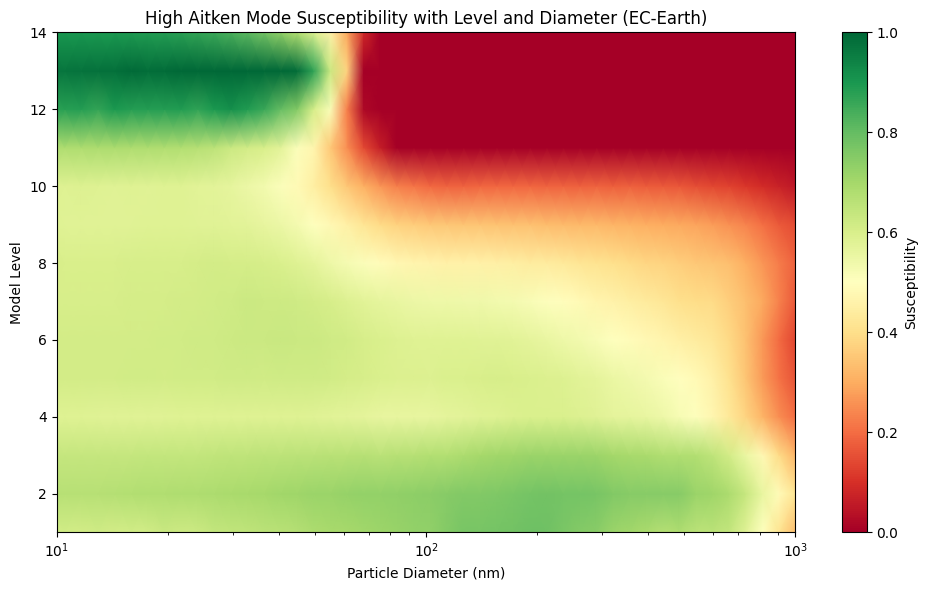

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
mesh = ax.pcolormesh(
    BigAitReg_lev_ds['radius'] * 2,
    BigAitReg_lev_ds['lev'],
    BigAitReg_lev_ds['slope'].T,
    shading='gouraud', vmin=0, vmax=1, cmap='RdYlGn',
)
ax.set_xscale('log')
ax.set_xlim(10, 1000)
ax.set_xlabel('Particle Diameter (nm)')
ax.set_ylabel('Model Level')
ax.set_title('High Aitken Mode Susceptibility with Level and Diameter (EC-Earth)')
plt.colorbar(mesh, ax=ax, label='Susceptibility')
plt.tight_layout()
plt.show()


## 9. Susceptibility vs particle diameter

Pooled slope (solid) and correlation r (dashed) vs cutoff diameter for each population.

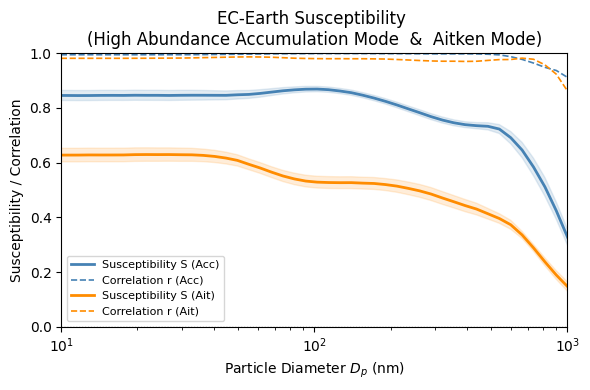

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
ds = BigAccReg_ds
ax.plot(ds['radius']*2, ds['slope'], color='steelblue', linewidth=2, label='Susceptibility S (Acc)')
ax.fill_between(ds['radius']*2,
                ds['slope'] - 1.98*ds['std_err'],
                ds['slope'] + 1.98*ds['std_err'],
                color='steelblue', alpha=0.15)
ax.plot(ds['radius']*2, ds['r_value'], '--', color='steelblue', linewidth=1.2, label='Correlation r (Acc)')
ds = BigAitReg_ds
ax.plot(ds['radius']*2, ds['slope'], color='darkorange', linewidth=2, label='Susceptibility S (Ait)')
ax.fill_between(ds['radius']*2,
                ds['slope'] - 1.98*ds['std_err'],
                ds['slope'] + 1.98*ds['std_err'],
                color='darkorange', alpha=0.15)
ax.plot(ds['radius']*2, ds['r_value'], '--', color='darkorange', linewidth=1.2, label='Correlation r (Ait)')
ax.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax.set_title('EC-Earth Susceptibility \n(High Abundance Accumulation Mode  &  Aitken Mode)')
ax.set_xlabel('Particle Diameter $D_p$ (nm)')
ax.set_ylabel('Susceptibility / Correlation')
ax.set_ylim([0, 1])
ax.set_xlim([10, 1000])
ax.set_xscale('log')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 10. Mode occurrence by model level

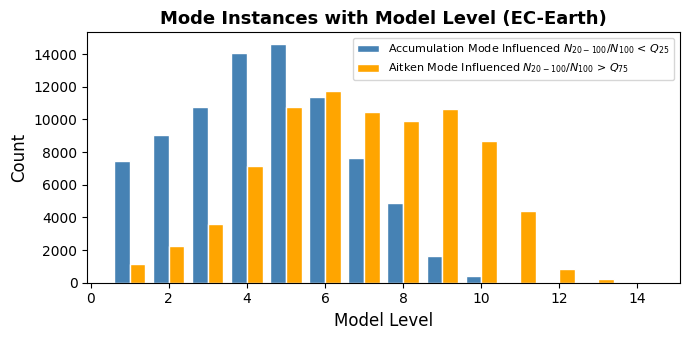

In [20]:
import numpy as np

# Count only valid (finite-CDNC) samples per level
acc_valid = np.isfinite(Pairs_acc.CDNC.values)
ait_valid = np.isfinite(Pairs_ait.CDNC.values)

acc_count = pd.Series(Pairs_acc.lev.values[acc_valid]).value_counts().sort_index()
ait_count = pd.Series(Pairs_ait.lev.values[ait_valid]).value_counts().sort_index()
all_levels = ait_count.index.union(acc_count.index)

acc_count = acc_count.reindex(all_levels, fill_value=0)
ait_count = ait_count.reindex(all_levels, fill_value=0)

all_levels_arr = np.array(all_levels, dtype=float)
min_spacing = np.diff(np.sort(all_levels_arr)).min()
width = min_spacing * 0.4

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(all_levels_arr - width/2, acc_count.values, width=width,
       color='steelblue', edgecolor='white', label='Accumulation Mode Influenced $N_{20-100}/N_{100}$ < $Q_{25}$')
ax.bar(all_levels_arr + width/2, ait_count.values, width=width,
       color='orange', edgecolor='white', label='Aitken Mode Influenced $N_{20-100}/N_{100}$ > $Q_{75}$')
ax.set_xlabel('Model Level', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Mode Instances with Model Level (EC-Earth)', fontsize=13, fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 11. Per-level susceptibility curves

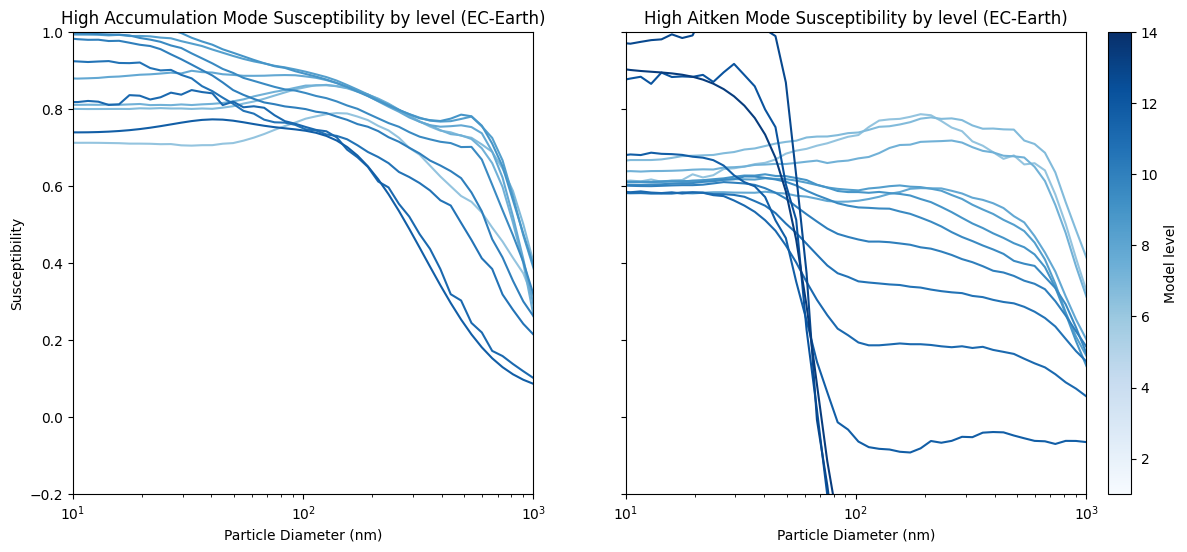

In [21]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# Per-level sample counts; keep only levels with > 1000 points
acc_count = pd.Series(Pairs_acc.lev.values).value_counts()
ait_count = pd.Series(Pairs_ait.lev.values).value_counts()

acc_levels = [l for l in BigAccReg_lev_ds.lev.values if acc_count.get(l, 0) > 1000]
ait_levels = [l for l in BigAitReg_lev_ds.lev.values if ait_count.get(l, 0) > 1000]

# Shared color scale across both panels (level -> color)
all_levels = np.array(acc_levels + ait_levels, dtype=float)
norm = Normalize(vmin=all_levels.min(), vmax=all_levels.max())
cmap = cm.Blues
def level_color(v):
    return cmap(0.4 + 0.55 * norm(v))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
panels = [
    (axes[0], BigAccReg_lev_ds, acc_levels, 'High Accumulation Mode Susceptibility by level (EC-Earth)'),
    (axes[1], BigAitReg_lev_ds, ait_levels, 'High Aitken Mode Susceptibility by level (EC-Earth)'),
]
for ax, ds, levels, title in panels:
    for lev_val in levels:
        ax.plot(ds.radius * 2, ds.slope.sel(lev=lev_val), color=level_color(lev_val))
    ax.set_xscale('log')
    ax.set_xlabel('Particle Diameter (nm)')
    ax.set_title(title)
    ax.set_xlim([10, 1000])
    ax.set_ylim([-0.2, 1])
axes[0].set_ylabel('Susceptibility')

sm = cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.046, pad=0.02)
cbar.set_label('Model level')
plt.show()


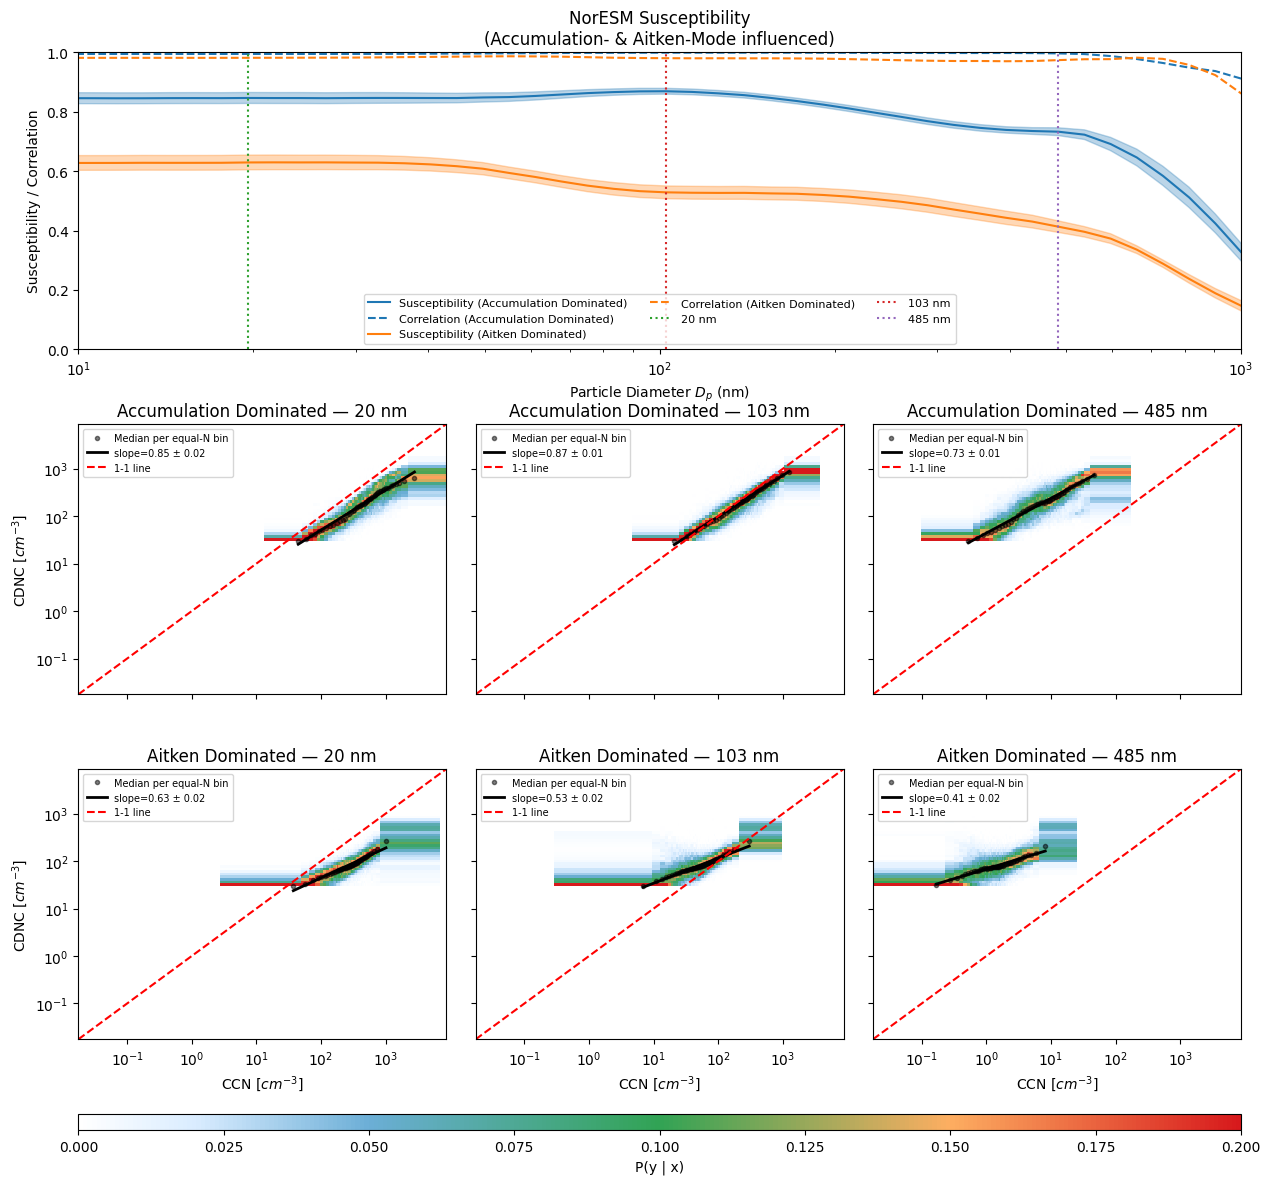

In [22]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, MaxNLocator

cmap = LinearSegmentedColormap.from_list(
    "paper_style",
    [
        (0.0,  "#ffffff"),
        (0.1,  "#d9ecff"),
        (0.25, "#6baed6"),
        (0.5,  "#31a354"),
        (0.75, "#fdae61"),
        (1.0,  "#d7191c"),
    ],
)

n_bins = 50
pow_fmt = FuncFormatter(lambda v, _: rf"$10^{{{int(v)}}}$")

# (label, regression ds, pairs ds, colour) for each mode
modes = [
    ("Accumulation Dominated", BigAccReg_ds, Pairs_acc, 'C0'),
    ("Aitken Dominated", BigAitReg_ds, Pairs_ait, 'C1'),
]

diam = BigAccReg_ds['radius'].values * 2  # nm; same radius grid for both

# --- choose the three cutoff indices (shared across both rows) ---
imax_acc = int(np.nanargmin(np.abs(diam - 500)))
imax_ait = int(np.nanargmin(np.abs(diam - 100)))
i20 = int(np.nanargmin(np.abs(diam - 20)))
panel_idxs = [i20, imax_ait, imax_acc]
panel_labels = [f'{diam[i20]:.0f} nm',
                f'{diam[imax_ait]:.0f} nm',
                f'{diam[imax_acc]:.0f} nm']


def panel_data(reg_ds, pairs_ds, ridx):
    ccn  = pairs_ds['CCN'].isel(radius=ridx).values.ravel()
    cdnc = pairs_ds['CDNC'].values.ravel()
    valid = np.isfinite(ccn) & np.isfinite(cdnc) & (ccn > 0) & (cdnc > 0)
    lx, ly = np.log10(ccn[valid]), np.log10(cdnc[valid])

    bins = np.unique(np.quantile(lx, np.linspace(0, 1, n_bins + 1)))
    lx_med, ly_med = [], []
    for b in range(len(bins) - 1):
        if b == len(bins) - 2:
            m = (lx >= bins[b]) & (lx <= bins[b+1])
        else:
            m = (lx >= bins[b]) & (lx < bins[b+1])
        if m.sum() >= 2:
            lx_med.append(np.median(lx[m]))
            ly_med.append(np.median(ly[m]))
    lx_med, ly_med = np.array(lx_med), np.array(ly_med)

    ybins = np.linspace(ly.min(), ly.max(), 30)
    H, xedges, yedges = np.histogram2d(lx, ly, bins=[bins, ybins])
    H_norm = np.nan_to_num(H / H.sum(axis=1, keepdims=True))

    return dict(
        lx=lx, ly=ly, lx_med=lx_med, ly_med=ly_med,
        xedges=xedges, yedges=yedges, H_norm=H_norm,
        slope=float(reg_ds['slope'].isel(radius=ridx)),
        intercept=float(reg_ds['intercept'].isel(radius=ridx)),
        std_err=float(reg_ds['std_err'].isel(radius=ridx)),
    )

# precompute all six panels + global shared range
pdata = {}
for label, reg_ds, pairs_ds, _ in modes:
    for ridx in panel_idxs:
        pdata[(label, ridx)] = panel_data(reg_ds, pairs_ds, ridx)

g_min = min(min(d['lx'].min(), d['ly'].min()) for d in pdata.values())
g_max = max(max(d['lx'].max(), d['ly'].max()) for d in pdata.values())

# --- layout: curve (row 0) + two histogram rows (1,2) + colorbar (row 3) ---
fig = plt.figure(figsize=(15, 14))
gs = fig.add_gridspec(4, 3, height_ratios=[1.1, 1, 1, 0.06],
                      hspace=0.35, wspace=0.08)

# top: shared susceptibility profile
ax_curve = fig.add_subplot(gs[0, :])
for label, reg_ds, _, colour in modes:
    sl = reg_ds['slope']
    se = reg_ds['std_err']
    ax_curve.plot(diam, sl, color=colour, label=f'Susceptibility ({label})')
    ax_curve.fill_between(diam, sl - 1.98*se, sl + 1.98*se, alpha=0.3, color=colour)
    ax_curve.plot(diam, reg_ds['r_value'], '--',
                  color=colour, label=f'Correlation ({label})')
for ridx, c in zip(panel_idxs, ['tab:green', 'tab:red', 'tab:purple']):
    ax_curve.axvline(diam[ridx], color=c, linestyle=':', label=f'{diam[ridx]:.0f} nm')
ax_curve.set_title('NorESM Susceptibility\n(Accumulation- & Aitken-Mode influenced)')
ax_curve.set_xlabel('Particle Diameter $D_p$ (nm)')
ax_curve.set_ylabel('Susceptibility / Correlation')
ax_curve.set_ylim([0, 1])
ax_curve.set_xlim([10, 1000])
ax_curve.set_xscale('log')
ax_curve.legend(ncols=3, fontsize=8)

# two histogram rows, sharing one common axis
first_ax = None
pcm = None
for row, (label, reg_ds, pairs_ds, colour) in enumerate(modes):
    for col, ridx in enumerate(panel_idxs):
        d = pdata[(label, ridx)]
        ax = fig.add_subplot(gs[1 + row, col],
                             sharex=first_ax, sharey=first_ax)
        if first_ax is None:
            first_ax = ax

        pcm = ax.pcolormesh(d['xedges'], d['yedges'], d['H_norm'].T,
                            cmap=cmap, shading="auto", vmin=0, vmax=0.2)
        ax.plot(d['lx_med'], d['ly_med'], "k.", alpha=0.5,
                label="Median per equal-N bin")
        xfit = np.array([d['lx_med'].min(), d['lx_med'].max()])
        ax.plot(xfit, d['intercept'] + d['slope'] * xfit, "k-", linewidth=2,
                label=f"slope={d['slope']:.2f} ± {1.98*d['std_err']:.2f}")
        ax.plot([g_min, g_max], [g_min, g_max], ls="--", c="red", label="1-1 line")

        ax.set_xlim(g_min, g_max)
        ax.set_ylim(g_min, g_max)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.xaxis.set_major_formatter(pow_fmt)
        ax.yaxis.set_major_formatter(pow_fmt)
        ax.set_title(f"{label} — {panel_labels[col]}")
        ax.legend(fontsize=7, loc='upper left')

        # x labels only on bottom row; y labels only on first column
        if row == len(modes) - 1:
            ax.set_xlabel("CCN [$cm^{-3}$]")
        else:
            ax.tick_params(labelbottom=False)
        if col == 0:
            ax.set_ylabel("CDNC [$cm^{-3}$]")
        else:
            ax.tick_params(labelleft=False)

# horizontal colorbar under everything
cax = fig.add_subplot(gs[3, :])
fig.colorbar(pcm, cax=cax, orientation='horizontal', label="P(y | x)")

plt.show()

Cutoff = 45 nm diameter (30th radius index)


/tmp/ipykernel_2028030/1999974833.py:32: RuntimeWarning: invalid value encountered in divide
  H1_norm = H1 / H1.sum(axis=1, keepdims=True)
/tmp/ipykernel_2028030/1999974833.py:33: RuntimeWarning: invalid value encountered in divide
  H2_norm = H2 / H2.sum(axis=1, keepdims=True)


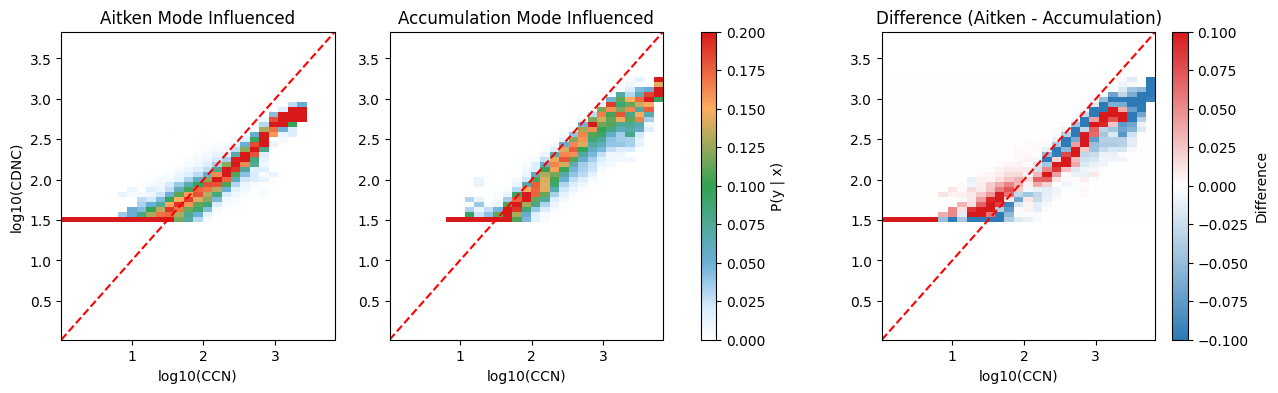

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
print(f'Cutoff = {2 * Pairs_ait.radius.isel(radius=30).values:2.0f} nm diameter (30th radius index)')
# --- Data ---
x1 = np.log10(Pairs_ait['CCN'].isel(radius=30))
y1 = np.log10(Pairs_ait['CDNC'])

x2 = np.log10(Pairs_acc['CCN'].isel(radius=30))
y2 = np.log10(Pairs_acc['CDNC'])

# Flatten & remove NaNs (important!)
x1, y1 = x1.values.flatten(), y1.values.flatten()
x2, y2 = x2.values.flatten(), y2.values.flatten()

mask1 = np.isfinite(x1) & np.isfinite(y1)
mask2 = np.isfinite(x2) & np.isfinite(y2)

x1, y1 = x1[mask1], y1[mask1]
x2, y2 = x2[mask2], y2[mask2]
Graph_min = np.min([np.min(x1),np.min(y1),np.min(x2),np.min(y2)])
Graph_max = np.max([np.max(x1),np.max(y1),np.max(x2),np.max(y2)])
# --- bin edges (shared!) ---
xbins = np.linspace(min(x1.min(), x2.min()), max(x1.max(), x2.max()), 30)
ybins = np.linspace(min(y1.min(), y2.min()), max(y1.max(), y2.max()), 30)

# --- Histograms ---
H1, xedges, yedges = np.histogram2d(x1, y1, bins=[xbins, ybins])
H2, _, _ = np.histogram2d(x2, y2, bins=[xbins, ybins])

# --- Normalize per x-bin ---
H1_norm = H1 / H1.sum(axis=1, keepdims=True)
H2_norm = H2 / H2.sum(axis=1, keepdims=True)

H1_norm = np.nan_to_num(H1_norm)
H2_norm = np.nan_to_num(H2_norm)

# --- Difference ---
H_diff = H1_norm - H2_norm

# --- Colormaps ---
cmap_main = LinearSegmentedColormap.from_list(
    "paper_style",
    [
        (0.0,  "#ffffff"),
        (0.1,  "#d9ecff"),
        (0.25, "#6baed6"),
        (0.5,  "#31a354"),
        (0.75, "#fdae61"),
        (1.0,  "#d7191c"),
    ]
)

cmap_diff = LinearSegmentedColormap.from_list(
    "diff_map",
    [
        (0.0, "#2c7bb6"),  # blue
        (0.5, "#ffffff"),  # zero
        (1.0, "#d7191c"),  # red
    ]
)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Aitken
pcm1 = axes[0].pcolormesh(
    xedges, yedges, H1_norm.T,
    cmap=cmap_main, shading='auto',
    vmin=0, vmax=0.2
)
axes[0].set_title('Aitken Mode Influenced')
axes[0].set_xlabel('log10(CCN)')
axes[0].set_ylabel('log10(CDNC)')
axes[0].set_ylim([Graph_min,Graph_max])
axes[0].set_xlim([Graph_min,Graph_max])
axes[0].plot([Graph_min,Graph_max],[Graph_min,Graph_max], label = '1-1 line', ls = '--', c = 'red')
# Accumulation
pcm2 = axes[1].pcolormesh(
    xedges, yedges, H2_norm.T,
    cmap=cmap_main, shading='auto',
    vmin=0, vmax=0.2
)
axes[1].set_title('Accumulation Mode Influenced')
axes[1].set_xlabel('log10(CCN)')
axes[1].set_ylim([Graph_min,Graph_max])
axes[1].set_xlim([Graph_min,Graph_max])
axes[1].plot([Graph_min,Graph_max],[Graph_min,Graph_max], label = '1-1 line', ls = '--', c = 'red')
# Difference
pcm3 = axes[2].pcolormesh(
    xedges, yedges, H_diff.T,
    cmap=cmap_diff, shading='auto',
    vmin=-0.1, vmax=0.1
)
axes[2].set_title('Difference (Aitken - Accumulation)')
axes[2].set_xlabel('log10(CCN)')
axes[2].set_ylim([Graph_min,Graph_max])
axes[2].set_xlim([Graph_min,Graph_max])
axes[2].plot([Graph_min,Graph_max],[Graph_min,Graph_max], label = '1-1 line', ls = '--', c = 'red')
# Colorbars
fig.colorbar(pcm1, ax=axes[:2], label='P(y | x)')
fig.colorbar(pcm3, ax=axes[2], label='Difference')

plt.show()